This notebook implements the Tidy3D script necessary to simulate the whole optical system (from input to output plane). It initializes the simulation domain by importing the necessary data, which consists of:
1) The input field at a pre-determined distance from the first metasurface
2) The first and second metasurface phase masks

In order to avoid simulating the whole empty space region between the two metasurfaces, far-field projection monitors are used. For example, consider the first metasurface (MS1). A custom source defined using the imported input field is placed at the appropriate distance from MS1. A far-field monitor is positioned after MS1 nano pillars and spans the entire simulation domain to capture the MS1 near field. We assume pillars are non-resonant within the diameters chosen. This assumption is reasonable given unit-cell simulations (see later). In other words, we can position the monitor sufficiently close above MS1 without worrying too much about evanescent fields. The monitor registers the near-fields and uses them to project the far-field. The far field is computed just before MS2. In the end, we can compute fields all the way to MS2 while simulating a thin region below and above MS1. After the fields have been projected, we set up the second simulation phase: simulating the effect of MS2. We use the projected fields to setup another custom source, placed in the same way as previously described. We follow a similar procedure for the rest of the simulation while paying extra care at selecting the rigt materials. Another far field projection is required after MS2. This time, it is used to compute the fields on the output plane.

In [2]:
import tidy3d as td
from tidy3d import web
from tidy3d import SimulationData

import numpy as np
import matplotlib.pyplot as plt

In [3]:
#all dimensions in [um]
lda0 = 1.55
lambda0 = lda0
freq0 = td.C_0 / lda0
fwidth = freq0 / 10

###################
#MATERIALS
n_si = 3.45 #silicon refractive index
si = td.Medium(permittivity = n_si ** 2)
n_sio2 = 1.45
sio2 = td.Medium(permittivity = n_sio2 ** 2)
n_air = 1.0 #air refractive index
air = td.Medium(permittivity = n_air ** 2)
###################

###################
#UNIT-CELL RELATED
P = 0.7 #unit cell pitch [um]
unit_cell_pitch = P
h = 0.9 #pillar height [um]
###################

###################
#PROPAGATION DISTANCES
d0 = 476 #[um]
d1 = 510 #[um]
d2 = d0 #[um]
###################

###################
#SPATIAL GRIDs
#FULL GRID
Nx = 1025 #pixels per dimension
Ny = Nx

#quadrant
nx = (Nx - 1) // 2 #indices without 0-axes (= #512)
ny = (Ny - 1) // 2
dof = 2*((nx + 1)**2) #number of degrees of freedom per metasurface (one quadrant)
S = Nx * Ny

size_x = unit_cell_pitch * Nx #actual physical size
size_y = unit_cell_pitch * Ny

xs = np.arange(-Nx//2+1, Nx//2+1) * (size_x / Nx)
ys = np.arange(-Ny//2+1, Ny//2+1) * (size_y / Ny)
X, Y = np.meshgrid(xs, ys)
rho = np.sqrt(X**2 + Y**2)

try:
    assert(len(xs) == Nx)
    assert(len(ys) == Ny)
    assert(xs[0] == xs[-1]*-1)
    assert(ys[0] == ys[-1]*-1)
    assert(xs[nx]==0)
    assert(ys[ny]==0)
    assert(np.abs(np.abs(xs[1]-xs[0]) - unit_cell_pitch) < 1e-12)
except:
    raise ValueError("Error while setting up the spatial grid.")

#SIMULATION GRID
fibre_cladding_diameter = 125 #[um]
max_available_diameter = 122 #[um] - maximum available metasurface footprint
max_sim_size = 140 #[um] maximum simulation size
max_sim_radius = max_sim_size / 2
sim_x_size = max_sim_size #x dimension [um] slightly larger than the metasurface footprint
sim_y_size = sim_x_size #y dimension [um]
sim_z_size = h + lda0 + 0.4

sim_mask = np.zeros((Nx, Ny),dtype=int)
for i in range(Nx):
    for j in range(Ny):
        if np.abs(X[i,j]) < sim_x_size/2 and np.abs(Y[i,j]) < sim_y_size/2:
            sim_mask[i,j] = 1
        else:
            sim_mask[i,j] = 0

Nx_sim = int(np.sum(sim_mask, axis=1).max())

Ny_sim = Nx_sim
nx_sim = (Nx_sim - 1) // 2 #indices without 0-axes (=#512)
ny_sim = (Ny_sim - 1) // 2 
xs_sim = np.arange(-Nx_sim//2+1, Nx_sim//2+1) * (sim_x_size / Nx_sim)
ys_sim = np.arange(-Ny_sim//2+1, Ny_sim//2+1) * (sim_y_size / Ny_sim)

X_sim, Y_sim = np.meshgrid(xs_sim, ys_sim)

#first quadrant of the simulation grid
nx_quadrant = (Nx_sim - 1) // 2 #quadrant simulation indices without 0-axes (= #512)
ny_quadrant = (Ny_sim - 1) // 2
xs_sim_quadrant = xs_sim[Nx_sim//2:]
ys_sim_quadrant = ys_sim[Ny_sim//2:]
X_sim_quadrant = X_sim[Ny_sim//2:, Nx_sim//2:]
Y_sim_quadrant = Y_sim[Ny_sim//2:, Nx_sim//2:]

print(f"Simulation grid size: {Nx_sim} x {Ny_sim} pixels, physical size: {sim_x_size} x {sim_y_size} um")
print("X_sim shape:", X_sim.shape)
print("Y_sim shape:", Y_sim.shape)
max_xs_sim_coord = np.max(xs_sim)
min_xs_sim_coord = np.min(xs_sim)
print(f"X_sim coordinates range: {min_xs_sim_coord} to {max_xs_sim_coord} um")
max_ys_sim_coord = np.max(ys_sim)
min_ys_sim_coord = np.min(ys_sim)
print(f"Y_sim coordinates range: {min_ys_sim_coord} to {max_ys_sim_coord} um")
print("Simulation quadrant shapes:", X_sim_quadrant.shape, Y_sim_quadrant.shape)
print("Simulation quadrant coordinate ranges:")
print(f"x_sim_quadrant coordinates range: {xs_sim_quadrant.min()} to {xs_sim_quadrant.max()} um")
print(f"y_sim_quadrant coordinates range: {ys_sim_quadrant.min()} to {ys_sim_quadrant.max()} um")

try:
    assert(len(xs_sim) == Nx_sim)
    assert(len(ys_sim) == Ny_sim)
    assert(xs_sim[0] == xs_sim[-1]*-1)
    assert(ys_sim[0] == ys_sim[-1]*-1)
    assert(xs_sim[Nx_sim//2]==0)
    assert(ys_sim[Ny_sim//2]==0)
    assert(np.abs(np.abs(xs_sim[1]-xs_sim[0]) - (sim_x_size / Nx_sim)) < 1e-12)
except:
    raise ValueError("Error while setting up the simulation grid.")

Simulation grid size: 199 x 199 pixels, physical size: 140 x 140 um
X_sim shape: (199, 199)
Y_sim shape: (199, 199)
X_sim coordinates range: -69.64824120603015 to 69.64824120603015 um
Y_sim coordinates range: -69.64824120603015 to 69.64824120603015 um
Simulation quadrant shapes: (100, 100) (100, 100)
Simulation quadrant coordinate ranges:
x_sim_quadrant coordinates range: 0.0 to 69.64824120603015 um
y_sim_quadrant coordinates range: 0.0 to 69.64824120603015 um


phase mask 1 minimum value: 0.0
phase mask 1 maximum value: 6.283185307179586


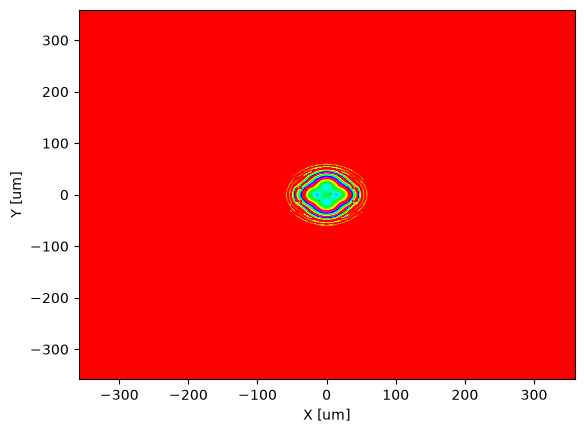

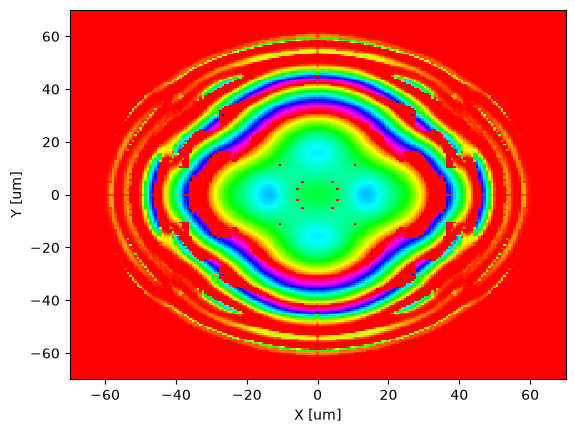

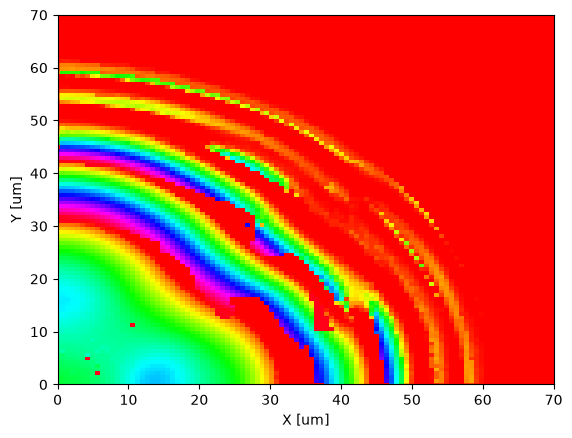

In [4]:
####################################################
#LOAD PHASE MASK 1
#___________________________________________________
#load the phase mask data
phase_mask_1_filename = "../results_sym/optimized_phase_mask_1.npy"
phase_mask_1 = np.load(phase_mask_1_filename)

fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y, phase_mask_1, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.show()

phase_mask_1_sim = phase_mask_1[sim_mask==1].reshape(Nx_sim, Ny_sim)
fig, ax = plt.subplots()
im = ax.pcolormesh(X_sim, Y_sim, phase_mask_1_sim, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.show()

phase_mask_1_quadrant = phase_mask_1_sim[nx_sim:, ny_sim:]
print("phase mask 1 minimum value:", np.min(phase_mask_1_quadrant))
print("phase mask 1 maximum value:", np.max(phase_mask_1_quadrant))

fig, ax = plt.subplots()
im = ax.pcolormesh(X_sim_quadrant, Y_sim_quadrant, phase_mask_1_quadrant, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_ybound(0,sim_y_size/2)
ax.set_xbound(0,sim_x_size/2)


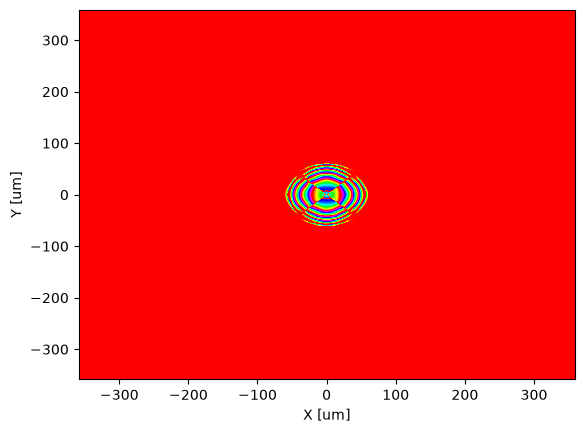

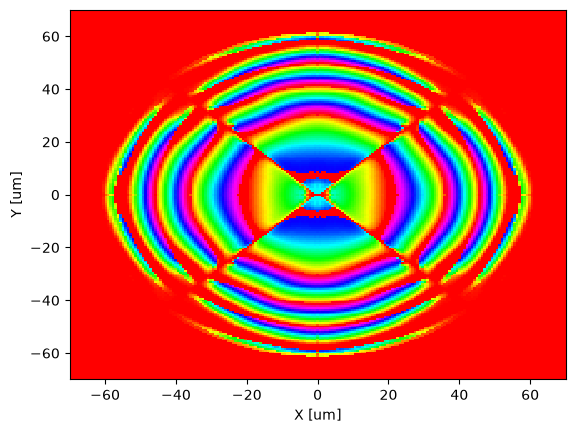

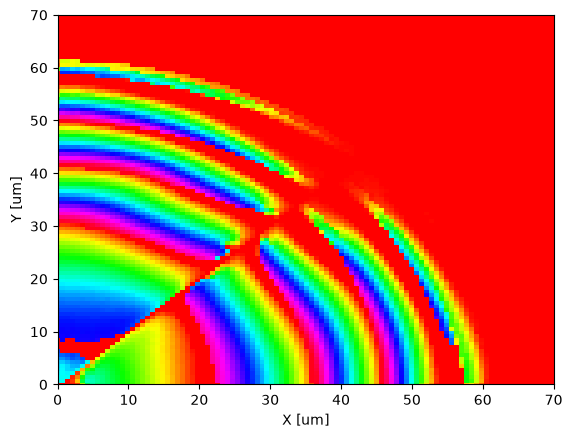

In [5]:
####################################################
#LOAD PHASE MASK 2
#___________________________________________________
#load the phase mask data
phase_mask_2_filename = "../results_sym/optimized_phase_mask_2.npy"
phase_mask_2 = np.load(phase_mask_2_filename)

fig, ax = plt.subplots()
im = ax.pcolormesh(X, Y, phase_mask_2, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.show()

phase_mask_2_sim = phase_mask_2[sim_mask==1].reshape(Nx_sim, Ny_sim)
fig, ax = plt.subplots()
im = ax.pcolormesh(X_sim, Y_sim, phase_mask_2_sim, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
fig.show()

phase_mask_2_quadrant = phase_mask_2_sim[nx_sim:, ny_sim:]

fig, ax = plt.subplots()
im = ax.pcolormesh(X_sim_quadrant, Y_sim_quadrant, phase_mask_2_quadrant, cmap='hsv', shading='auto')
ax.set_xlabel('X [um]')
ax.set_ylabel('Y [um]')
ax.set_ybound(0,sim_y_size/2)
ax.set_xbound(0,sim_x_size/2)

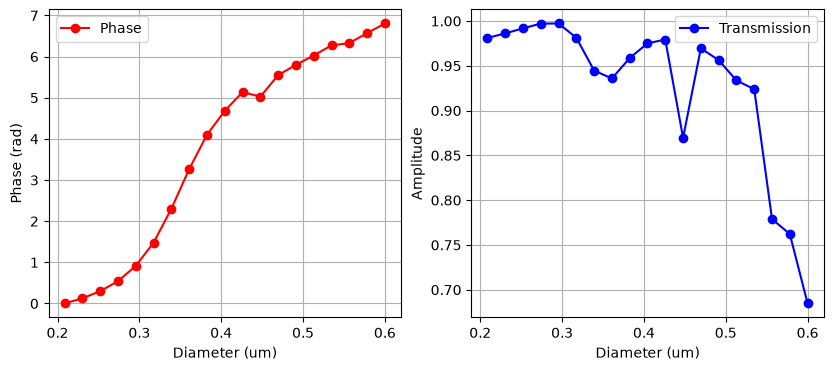

In [6]:
####################################################
#UNIT CELL DATA
#___________________________________________________
#import the unit-cell transmission coefficient data
start_index = 5
unit_cell_diameters = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_diameters.npy")[start_index:]
unit_cell_mode_phase = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_mode_phase.npy")[start_index:]
unit_cell_mode_phase = np.unwrap(unit_cell_mode_phase - unit_cell_mode_phase[0]) #smallest diameter gets normalized to 0 phase
unit_cell_mode_tran = np.load("../unit_cell/unit_cell_center_1550_h900nm_res50_wvl_mode_tran.npy")[start_index:]

#make a plot of the unit-cell transmission coefficient
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(unit_cell_diameters, unit_cell_mode_phase, 'r-', marker='o', label='Phase')
ax[0].set_xlabel('Diameter (um)')
ax[0].set_ylabel('Phase (rad)')
ax[0].grid()
ax[0].legend()
ax[1].plot(unit_cell_diameters, unit_cell_mode_tran, 'b-', marker='o', label='Transmission')
ax[1].set_xlabel('Diameter (um)')
ax[1].set_ylabel('Amplitude')
ax[1].grid()
ax[1].legend()

plt.show()
####################################################

In [7]:
pillars_geo_mask_1 = []
D_vals_mask_1 = []
theta = unit_cell_mode_phase

for i, x in enumerate(xs_sim_quadrant):
    for j, y in enumerate(ys_sim_quadrant):
        if np.sqrt(x**2 + y**2) > max_available_diameter/2:
            continue
        else:
            required_diameter = np.interp(phase_mask_1_quadrant[i,j], theta, unit_cell_diameters)
            #round the required diameter up to three decimal places (nm)
            required_diameter = np.round(required_diameter, 3)
            D_vals_mask_1.append(required_diameter)
            pillar_geo = td.Cylinder(center=(x, y, h/2), radius=required_diameter/2, length=h)
            pillars_geo_mask_1.append(pillar_geo)
print("Number of pillars in simulation domain: ", len(pillars_geo_mask_1))
pillars_mask_1 = td.Structure(geometry=td.GeometryGroup(geometries=pillars_geo_mask_1), medium=si)
print("Max pillar diameter:", np.max(D_vals_mask_1))
print("Min pillar diameter:", np.min(D_vals_mask_1))

Number of pillars in simulation domain:  5992
Max pillar diameter: 0.539
Min pillar diameter: 0.209


In [8]:
pillars_geo_mask_2 = []
D_vals_mask_2 = []
theta = unit_cell_mode_phase

for i, x in enumerate(xs_sim_quadrant):
    for j, y in enumerate(ys_sim_quadrant):
        if np.sqrt(x**2 + y**2) > max_available_diameter/2:
            continue
        else:
            required_diameter = np.interp(phase_mask_2_quadrant[i,j], theta, unit_cell_diameters)
            #round the required diameter up to three decimal places (nm)
            required_diameter = np.round(required_diameter, 3)
            D_vals_mask_2.append(required_diameter)
            pillar_geo = td.Cylinder(center=(x, y, -h/2), radius=required_diameter/2, length=h)
            pillars_geo_mask_2.append(pillar_geo)
print("Number of pillars_mask_2 in simulation domain: ", len(pillars_geo_mask_2))
pillars_mask_2 = td.Structure(geometry=td.GeometryGroup(geometries=pillars_geo_mask_2), medium=si)
print("Max pillar diameter:", np.max(D_vals_mask_2))
print("Min pillar diameter:", np.min(D_vals_mask_2))

Number of pillars_mask_2 in simulation domain:  5992
Max pillar diameter: 0.539
Min pillar diameter: 0.209


In [9]:
#substrate td.Structure definitions
inf_eff = 1e5
substrate_geo_below = td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, 0))
substrate_below = td.Structure(geometry=substrate_geo_below, medium=sio2)

substrate_geo_above = td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, 0), rmax=(inf_eff, inf_eff, inf_eff))
substrate_above = td.Structure(geometry=substrate_geo_above, medium=sio2)

all_substrate_geo = td.Box.from_bounds(rmin=(-inf_eff, -inf_eff, -inf_eff), rmax=(inf_eff, inf_eff, inf_eff))
all_substrate = td.Structure(geometry=all_substrate_geo, medium=sio2) 

Input field shape: (1025, 1025)
minimum field magnitude: 8.841660535436755e-05
Input field simulation shape: (199, 199)


Text(0, 0.5, 'Phase')

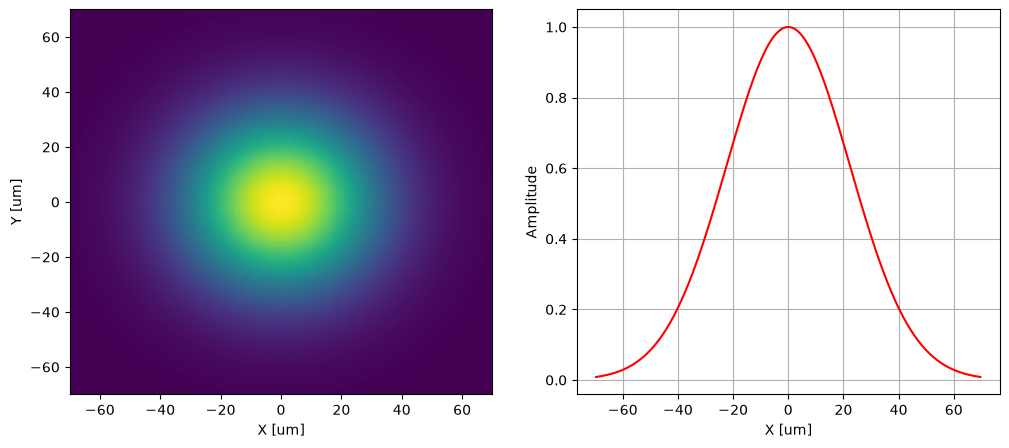

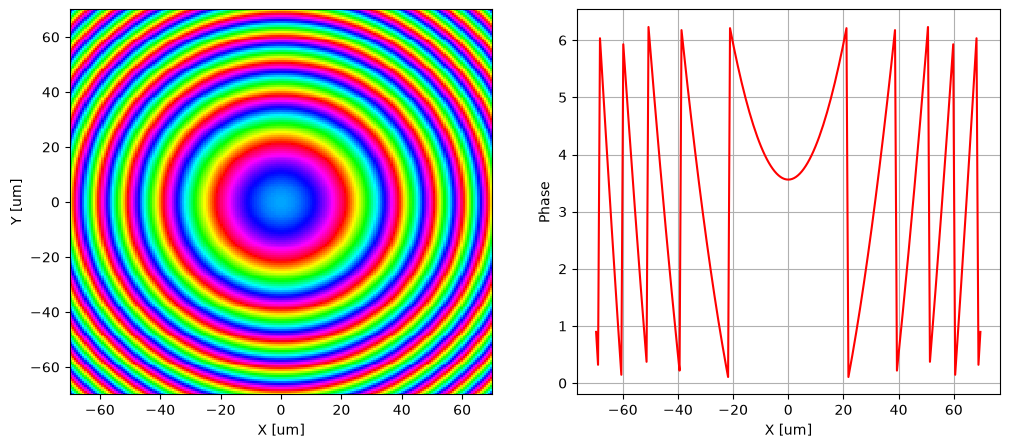

In [10]:
#import the input field (just before MS1)
input_field_before_MS1 = np.load("../results_sym/input_field_before_MS1.npy")
print("Input field shape:", input_field_before_MS1.shape)

input_field_before_MS1_sim = input_field_before_MS1[sim_mask==1].reshape(Nx_sim, Ny_sim)
input_field_before_MS1_sim = input_field_before_MS1_sim / np.max(np.abs(input_field_before_MS1_sim))
print("minimum field magnitude:", np.min(np.abs(input_field_before_MS1_sim)))
print("Input field simulation shape:", input_field_before_MS1_sim.shape)

#make two plots, one for the amplitude and one for the phase, 
# each of which consists of two subplots: a 2d plot and a 1d plot along the x-axis at y=0
fig, ax = plt.subplots(1,2, figsize=(12, 5))
im = ax[0].pcolormesh(X_sim, Y_sim, np.abs(input_field_before_MS1_sim), shading='auto')
ax[0].set_xlabel('X [um]')
ax[0].set_ylabel('Y [um]')
am_cut = ax[1].plot(xs_sim, np.abs(input_field_before_MS1_sim[ny_sim,:]), 'r-')
ax[1].grid()
ax[1].set_xlabel('X [um]')
ax[1].set_ylabel('Amplitude')

fig, ax = plt.subplots(1,2, figsize=(12, 5))
im = ax[0].pcolormesh(X_sim, Y_sim, (np.angle(input_field_before_MS1_sim)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv')
ax[0].set_xlabel('X [um]')
ax[0].set_ylabel('Y [um]')
am_cut = ax[1].plot(xs_sim, (np.angle(input_field_before_MS1_sim[ny_sim,:])+2*np.pi)%(2*np.pi), 'r-')
ax[1].grid()
ax[1].set_xlabel('X [um]')
ax[1].set_ylabel('Phase')


In [11]:
#custom source field definition
source_position_1 = - (lda0 / 2)
source_time = td.GaussianPulse(freq0=freq0, fwidth=fwidth, phase=0)

source_x_size = max_sim_size
source_y_size = max_sim_size

source_Efield_sim = input_field_before_MS1_sim
substrate_impedance = td.ETA_0 / n_sio2

dataset_input_EH_1 = td.FieldDataset(
    Ex = td.ScalarFieldDataArray(
        source_Efield_sim[..., None, None],
        coords={
            "x": xs_sim,
            "y": ys_sim,
            "z": [source_position_1],
            "f": [freq0],
        },
    ),
    Hy = td.ScalarFieldDataArray(
        source_Efield_sim[..., None, None] / substrate_impedance,
        coords={
            "x": xs_sim,
            "y": ys_sim,
            "z": [source_position_1],
            "f": [freq0],
        },
    ),
)

custom_src_1 = td.CustomFieldSource(
    source_time = source_time,
    center = (0, 0, source_position_1),
    size = (source_x_size, source_y_size, 0),
    field_dataset = dataset_input_EH_1
)

run_time = 5e-12

In [12]:
#simulation
grid_per_unit_length = 15
grid_x = td.UniformGrid(dl = unit_cell_pitch / grid_per_unit_length)
#grid_x = td.AutoGrid(min_steps_per_wvl=grid_per_unit_length)
grid_y = td.UniformGrid(dl = unit_cell_pitch / grid_per_unit_length)
#grid_y = td.AutoGrid(min_steps_per_wvl=grid_per_unit_length)
grid_z = td.AutoGrid(min_steps_per_wvl=grid_per_unit_length)
grid_spec = td.GridSpec(wavelength=lda0, grid_x = grid_x, grid_y = grid_y, grid_z = grid_z)

#we overlay a box structure over the position of the pillars. This is done for the following reason.
#The meshing over the pillars requires many steps, since the refractive index changes
#from pillar to air. Instead of having to parse all these transitions, especially since we
#have a large number of pillars, we can simply overlay a box of the same material as the pillars.
#In this way, preprocessing becomes faster because all the region is treated uniformly. 
# The material is the same as the pillars, i.e., silicon
#to ensure the mesh is finer, compared to the surrounding air.

grid_spec_1 = grid_spec.copy(
    update = dict(
        override_structures=[
            td.Structure(
                geometry=td.Box.from_bounds(
                    rmin = (-td.inf, -td.inf, 0),
                    rmax = (td.inf, td.inf, h)
                ),
                medium = si,
            )
        ]
    )
)

grid_spec_2 = grid_spec.copy(
    update = dict(
        override_structures=[
            td.Structure(
                geometry=td.Box.from_bounds(
                    rmin = (-td.inf, -td.inf, -h),
                    rmax = (td.inf, td.inf, 0)
                ),
                medium = si,
            )
        ]
    )
)

In [13]:
#simulation domain size
Lx = max_sim_size
Ly = max_sim_size
Lz = sim_z_size

In [14]:
#flux monitors to compute reflectance and transmittance
transmittance_flux_monitor_1 = td.FluxMonitor(
    center=[0, 0, h + lda0/2],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="transmittance_flux_monitor_1",
)

reflectance_flux_monitor_1 = td.FluxMonitor(
    center=[0, 0, - (lda0/2 + 0.1)],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="reflectance_flux_monitor_1",
)

transmittance_flux_monitor_2 = td.FluxMonitor(
    center=[0, 0, lda0/2],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="transmittance_flux_monitor_2",
)

reflectance_flux_monitor_2 = td.FluxMonitor(
    center=[0, 0, - (h + lda0/2 + 0.1)],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="reflectance_flux_monitor_2",
)

In [15]:
#far field points the projection monitor will compute the field at
xs_far = np.linspace(-Lx/2, Lx/2, 201)
ys_far = np.linspace(-Ly/2, Ly/2, 201)
X_far, Y_far = np.meshgrid(xs_far, ys_far)

#distance from the monitor custom origin to the far-field plane
projection_distance = d1 - lda0 / 2

monitor_proj = td.FieldProjectionCartesianMonitor(
    center=[0, 0, h + 0.5*lda0],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="ff_proj_monitor",
    proj_axis=2,
    proj_distance=projection_distance,
    x=xs_far,
    y=ys_far,
    custom_origin=(0, 0, h),
    far_field_approx=False,
)

16:23:16 CEST WARNING: Override structures take no effect along x-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

              WARNING: Override structures take no effect along y-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

              WARNING: Override structures take no effect along x-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

              WARNING: Override structures take no effect along y-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

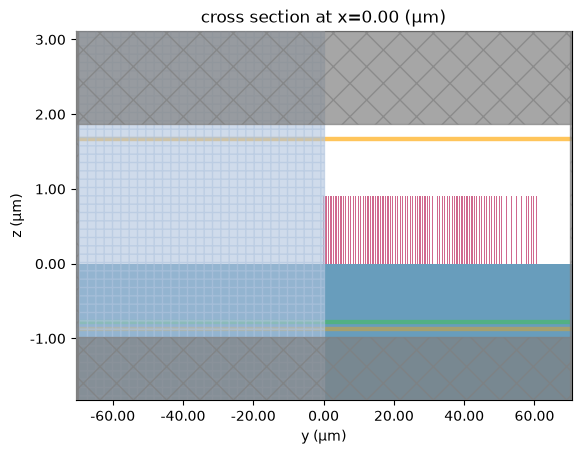

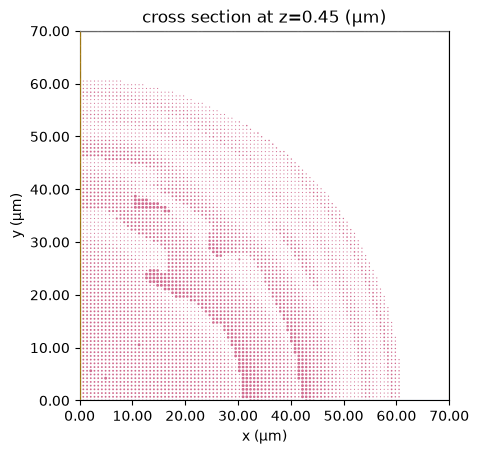

In [16]:
sim_normalization = td.Simulation(
    center=[0, 0, h/2],
    size=[Lx, Ly, Lz],
    grid_spec=grid_spec_1,
    structures=[all_substrate],
    sources=[custom_src_1],
    monitors=[reflectance_flux_monitor_1, transmittance_flux_monitor_1, monitor_proj],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()),
    symmetry=[-1,1,0],
)

sim1 = td.Simulation(
    center=[0, 0, h/2],
    size=[Lx, Ly, Lz],
    grid_spec=grid_spec_1,
    structures=[substrate_below, pillars_mask_1],
    sources=[custom_src_1],
    monitors=[reflectance_flux_monitor_1, transmittance_flux_monitor_1, monitor_proj],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()),
    symmetry=[-1,1,0],
)

fig, ax = plt.subplots()
sim1.plot(x=0, ax=ax,)
ax.set_aspect('auto')
plt.show()

fig, ax = plt.subplots()
sim1.plot(z=h/2, ax=ax, rasterized=True)
plt.xlim(0,Lx/2)
plt.ylim(0,Ly/2)
plt.show()
#plt.savefig("simulation_domain.pdf", bbox_inches='tight')

In [17]:
""" job = web.Job(simulation=sim_normalization, task_name="full_meta_normalization")
estimated_cost = web.estimate_cost(job.task_id) """

' job = web.Job(simulation=sim_normalization, task_name="full_meta_normalization")\nestimated_cost = web.estimate_cost(job.task_id) '

In [18]:
#job = web.Job(simulation=sim1, task_name="full_meta1")
#estimated_cost = web.estimate_cost(job.task_id)

In [19]:
#sim_data = job.run(path="full_meta_results/full_meta1.hdf5")

16:23:25 CEST WARNING: Override structures take no effect along x-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

              WARNING: Override structures take no effect along y-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

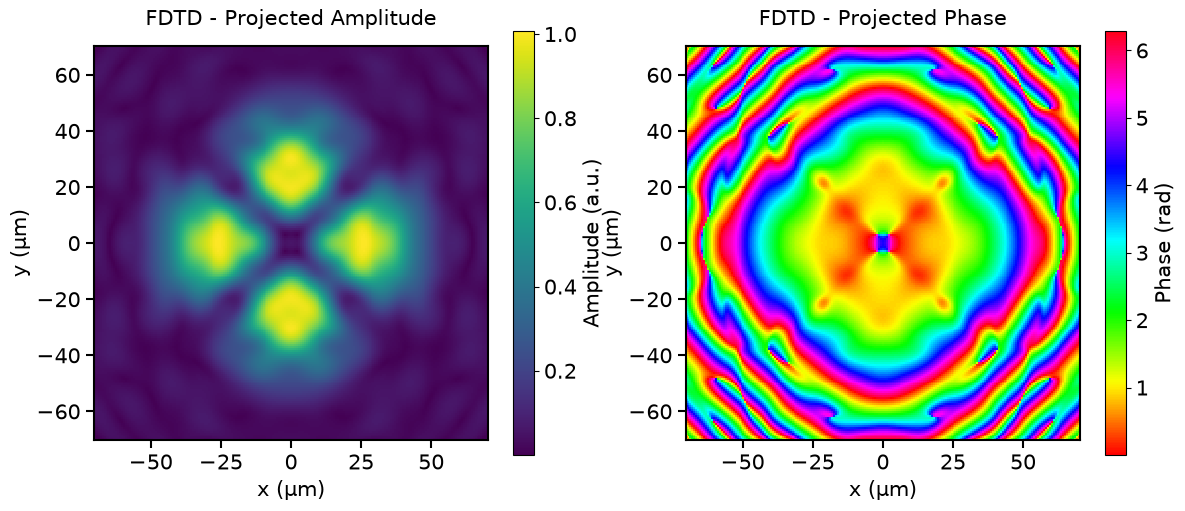

In [20]:
sim_data = SimulationData.from_file(fname="full_meta_results/full_meta1.hdf5")
proj_fields = sim_data["ff_proj_monitor"].fields_cartesian.Ex.sel(f=freq0, z=projection_distance)
np.save("full_meta_results/full_meta1_proj_fields.npy", proj_fields)
fig, ax = plt.subplots(1,2,figsize=(14, 5.5),)

im0 = ax[0].pcolormesh(X_far, Y_far, np.abs(proj_fields), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("y (μm)", fontsize=15,)
ax[0].set_title("FDTD - Projected Amplitude", fontsize=15, pad=15)
ax[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=ax[0], label="Amplitude (a.u.)")
cbar0.set_label("Amplitude (a.u.)", fontsize=15)
cbar0.ax.tick_params(labelsize=15)

im1 = ax[1].pcolormesh(X_far, Y_far, (np.angle(proj_fields)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_title("FDTD - Projected Phase", fontsize=15, pad=15)
ax[1].set_xlabel("x (μm)", fontsize=15,)
ax[1].set_ylabel("y (μm)", fontsize=15,)
ax[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax[1], label="Phase (rad)")
cbar1.set_label("Phase (rad)", fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.savefig("full_meta_results/full_meta1_proj_fields.pdf", bbox_inches='tight', dpi=300)

In [21]:
source_position_2 = - (h + 0.5 * lda0)
Nx_far = 201
Ny_far = 201
input_field_before_MS2_sim = np.load("full_meta_results/full_meta1_proj_fields.npy").reshape(Nx_far, Ny_far)
source_Efield_2_sim = input_field_before_MS2_sim
vacuum_impedance = td.ETA_0

dataset_input_EH_2 = td.FieldDataset(
    Ex = td.ScalarFieldDataArray(
        source_Efield_2_sim[..., None, None],
        coords={
            "x": xs_far,
            "y": ys_far,
            "z": [source_position_2],
            "f": [freq0],
        },
    ),
    Hy = td.ScalarFieldDataArray(
        source_Efield_2_sim[..., None, None] / vacuum_impedance,
        coords={
            "x": xs_far,
            "y": ys_far,
            "z": [source_position_2],
            "f": [freq0],
        },
    ),
)

custom_src_2 = td.CustomFieldSource(
    source_time = source_time,
    center = (0, 0, source_position_2),
    size = (source_x_size, source_y_size, 0),
    field_dataset = dataset_input_EH_2
)

In [22]:
projection_distance_output_field = d2

monitor_proj_output_field = td.FieldProjectionCartesianMonitor(
    center=[0, 0, 0.5*lda0],
    size=[td.inf, td.inf, 0],
    freqs=[freq0],
    name="ff_proj_monitor_output_field",
    proj_axis=2,
    proj_distance=projection_distance_output_field,
    x=xs_far,
    y=ys_far,
    custom_origin=(0, 0, 0),
    far_field_approx=False,
)

16:23:26 CEST WARNING: Override structures take no effect along x-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

              WARNING: Override structures take no effect along y-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

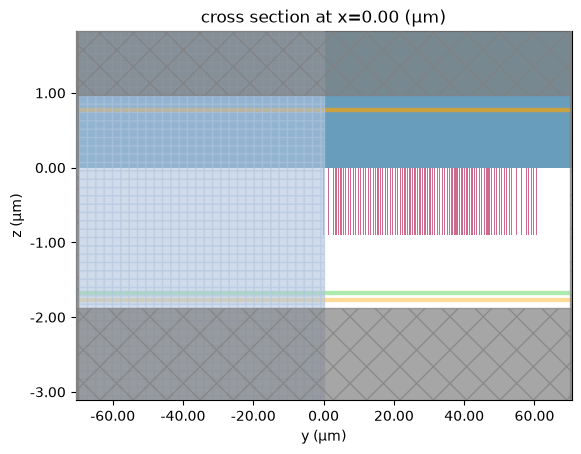

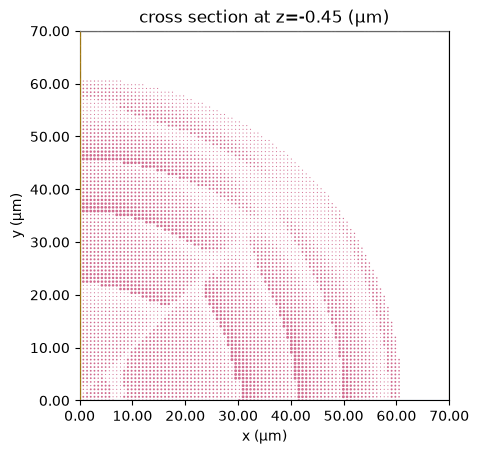

In [23]:
sim2 = td.Simulation(
    center=[0, 0, -h/2],
    size=[Lx, Ly, Lz],
    grid_spec=grid_spec_2,
    structures=[substrate_above, pillars_mask_2],
    sources=[custom_src_2],
    monitors=[reflectance_flux_monitor_2, transmittance_flux_monitor_2, monitor_proj_output_field],
    run_time=run_time,
    boundary_spec=td.BoundarySpec(x=td.Boundary.pml(), y=td.Boundary.pml(), z=td.Boundary.pml()),
    symmetry=[-1,1,0],
)

fig, ax = plt.subplots()
sim2.plot(x=0, ax=ax,)
ax.set_aspect('auto')
plt.show()

fig, ax = plt.subplots()
sim2.plot(z=-h/2, ax=ax, rasterized=True)
plt.xlim(0,Lx/2)
plt.ylim(0,Ly/2)
plt.show()
#plt.savefig("simulation_domain_2.pdf", bbox_inches='tight')

In [24]:
#job = web.Job(simulation=sim2, task_name="full_meta2")
#estimated_cost = web.estimate_cost(job.task_id)

In [25]:
#sim_data_2 = job.run(path="full_meta_results/full_meta2.hdf5")

16:23:35 CEST WARNING: Override structures take no effect along x-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

              WARNING: Override structures take no effect along y-axis. If      
              intending to apply override structures to this axis, use          
              'AutoGrid' or 'QuasiUniformGrid'.                                 

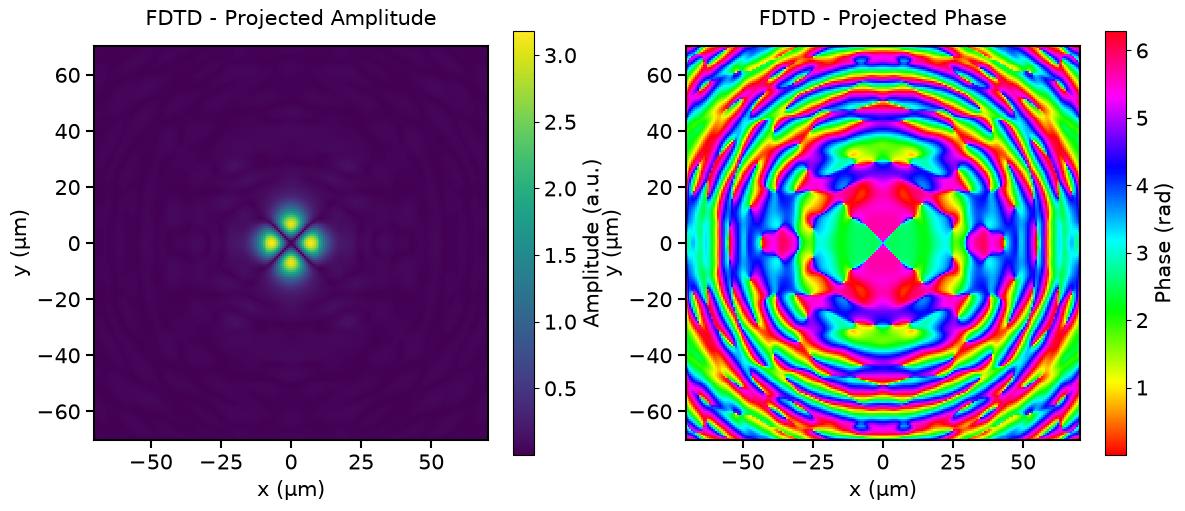

In [26]:
sim_data_2 = SimulationData.from_file(fname="full_meta_results/full_meta2.hdf5")
proj_fields_2 = sim_data_2["ff_proj_monitor_output_field"].fields_cartesian.Ex.sel(f=freq0, z=projection_distance_output_field)
np.save("full_meta_results/full_meta2_proj_fields.npy", proj_fields_2)
fig, ax = plt.subplots(1,2,figsize=(14, 5.5),)

im0 = ax[0].pcolormesh(X_far, Y_far, np.abs(proj_fields_2), shading='auto', cmap='viridis',rasterized=True)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("y (μm)", fontsize=15,)
ax[0].set_title("FDTD - Projected Amplitude", fontsize=15, pad=15)
ax[0].set_aspect('equal')
cbar0 = plt.colorbar(im0, ax=ax[0], label="Amplitude (a.u.)")
cbar0.set_label("Amplitude (a.u.)", fontsize=15)
cbar0.ax.tick_params(labelsize=15)

im1 = ax[1].pcolormesh(X_far, Y_far, (np.angle(proj_fields_2)+2*np.pi)%(2*np.pi), shading='auto', cmap='hsv',rasterized=True)
ax[1].set_title("FDTD - Projected Phase", fontsize=15, pad=15)
ax[1].set_xlabel("x (μm)", fontsize=15,)
ax[1].set_ylabel("y (μm)", fontsize=15,)
ax[1].set_aspect('equal')
cbar1 = plt.colorbar(im1, ax=ax[1], label="Phase (rad)")
cbar1.set_label("Phase (rad)", fontsize=15)
cbar1.ax.tick_params(labelsize=15)

for ax_item in ax:
    ax_item.tick_params(labelsize=15, width=1.5, length=6)
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

#save the figure to a PDF file
plt.savefig("full_meta_results/full_meta2_proj_fields.pdf", bbox_inches='tight', dpi=300)

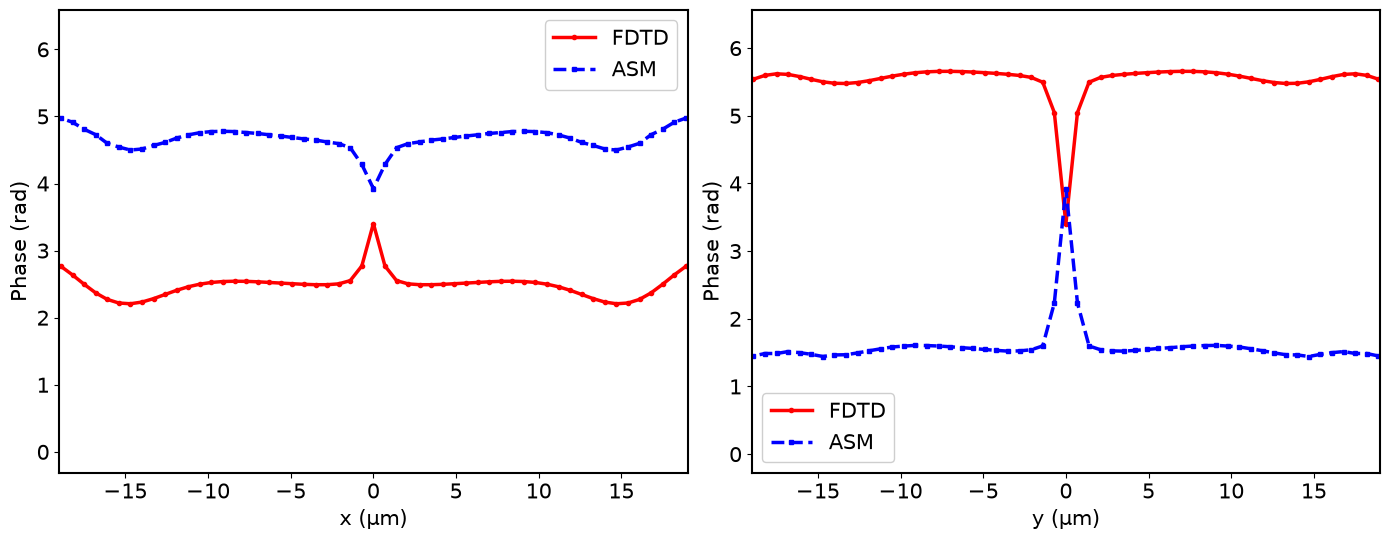

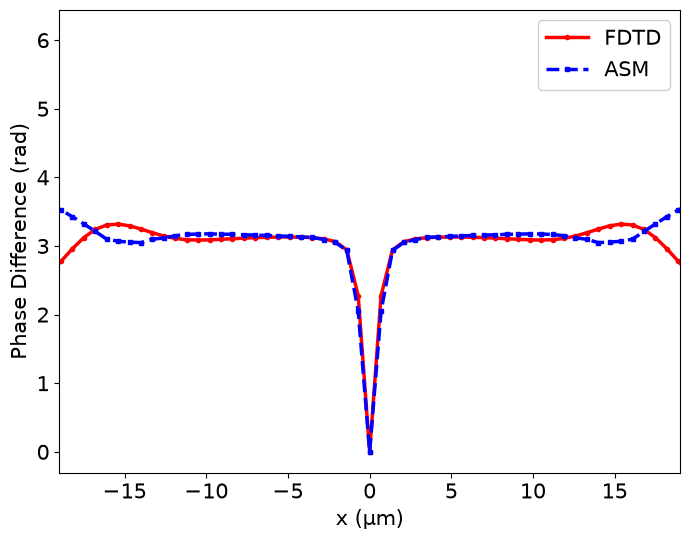

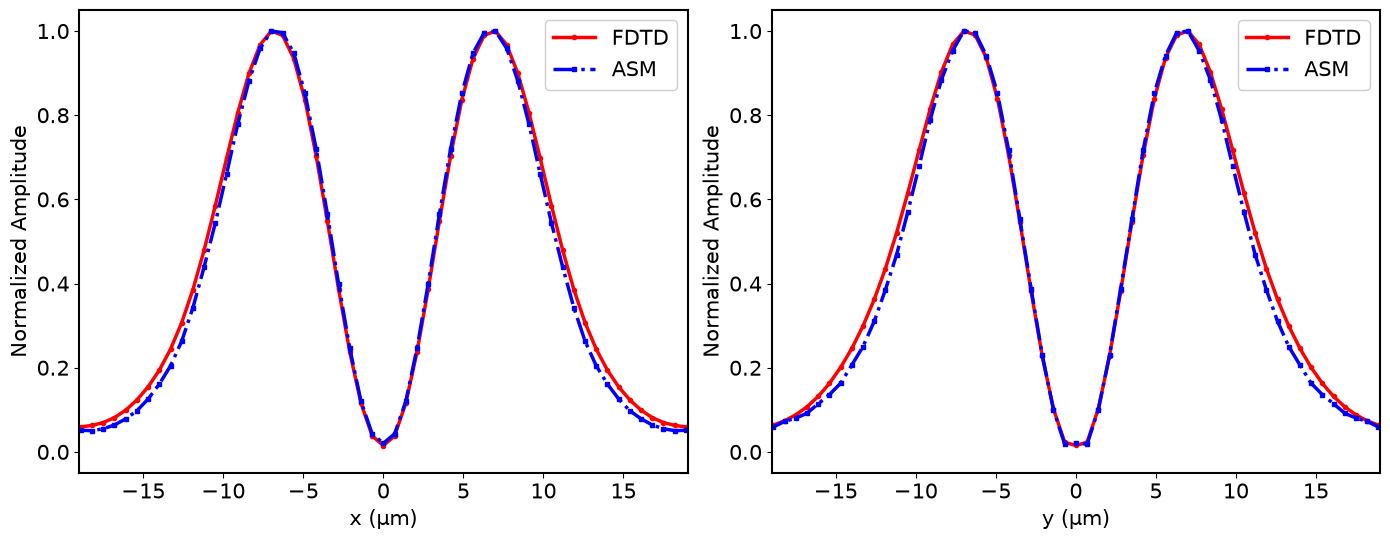

In [29]:
#import ASM fields
asm_output_field = np.load("../results_sym/optimized_output_field.npy")
output_fiber_core_diameter = 19
#make a 1D slice to compare phase of projected and intermediate ASM fields
#phase
projected_field_MS2_slice_x = proj_fields_2.x
projected_field_MS2_slice_xCut = proj_fields_2[X_far.shape[0]//2, :]
projected_field_MS2_slice_y = proj_fields_2.y
projected_field_MS2_slice_yCut = proj_fields_2[:,Y_far.shape[0]//2]

asm_output_field_slice_xCut = asm_output_field[X.shape[0]//2,:]
asm_output_field_slice_x = X[X.shape[0]//2,:]
asm_output_field_slice_yCut = asm_output_field[:,Y.shape[0]//2]
asm_output_field_slice_y = Y[:,Y.shape[0]//2]

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].plot(projected_field_MS2_slice_x, (np.angle(projected_field_MS2_slice_xCut)+2*np.pi)%(2*np.pi),
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[0].plot(asm_output_field_slice_x, (np.angle(asm_output_field_slice_xCut)+2*np.pi)%(2*np.pi),
           '--b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("Phase (rad)", fontsize=15,)
ax[0].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[0].tick_params(labelsize=15)
ax[0].legend(fontsize=15, loc='best', framealpha=0.95)


ax[1].plot(projected_field_MS2_slice_y, (np.angle(projected_field_MS2_slice_yCut)+2*np.pi)%(2*np.pi),
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[1].plot(asm_output_field_slice_y, (np.angle(asm_output_field_slice_yCut)+2*np.pi)%(2*np.pi),
           '--b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[1].set_xlabel("y (μm)", fontsize=15,)
ax[1].set_ylabel("Phase (rad)", fontsize=15,)
ax[1].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[1].tick_params(labelsize=15)
ax[1].legend(fontsize=15, loc='best', framealpha=0.95)


for ax_item in ax:
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
#plt.savefig("full_meta_results/fdtd_vs_asm_output_field_phase.pdf")
plt.close()

#relative phase difference between x and y spatial slices for both FDTD and ASM fields
fig, ax = plt.subplots(figsize=(7, 5.5))
fdtd_phase_diff = np.abs((np.angle(projected_field_MS2_slice_xCut)+2*np.pi)%(2*np.pi) - (np.angle(projected_field_MS2_slice_yCut)+2*np.pi)%(2*np.pi))
asm_phase_diff = np.abs((np.angle(asm_output_field_slice_xCut)+2*np.pi)%(2*np.pi) - (np.angle(asm_output_field_slice_yCut)+2*np.pi)%(2*np.pi))
ax.plot(projected_field_MS2_slice_x, fdtd_phase_diff,
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax.plot(asm_output_field_slice_x, asm_phase_diff,
           '--b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax.set_xlabel("x (μm)", fontsize=15,)
ax.set_ylabel("Phase Difference (rad)", fontsize=15,)
ax.set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax.tick_params(labelsize=15)
ax.legend(fontsize=15, loc='best', framealpha=0.95)
plt.tight_layout()
plt.show()
#plt.savefig("full_meta_results/differential_output_field_phase.pdf")
plt.close()

#amplitudes
normalized_projected_field_MS2_xCut = np.abs(projected_field_MS2_slice_xCut) / np.max(np.abs(projected_field_MS2_slice_xCut))
normalized_asm_output_field_xCut = np.abs(asm_output_field_slice_xCut) / np.max(np.abs(asm_output_field_slice_xCut))
normalized_projected_field_MS2_yCut = np.abs(projected_field_MS2_slice_yCut) / np.max(np.abs(projected_field_MS2_slice_yCut))
normalized_asm_output_field_yCut = np.abs(asm_output_field_slice_yCut) / np.max(np.abs(asm_output_field_slice_yCut))

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
ax[0].plot(projected_field_MS2_slice_x, normalized_projected_field_MS2_xCut,
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[0].plot(asm_output_field_slice_x, normalized_asm_output_field_xCut,
           '-.b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[0].set_xlabel("x (μm)", fontsize=15,)
ax[0].set_ylabel("Normalized Amplitude", fontsize=15,)
ax[0].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[0].tick_params(labelsize=15)
ax[0].legend(fontsize=15, loc='best', framealpha=0.95)


ax[1].plot(projected_field_MS2_slice_y, normalized_projected_field_MS2_yCut,
           'r', label="FDTD", linewidth=2.5, marker='o', markersize=3,)
ax[1].plot(asm_output_field_slice_y, normalized_asm_output_field_yCut,
           '-.b', label="ASM", linewidth=2.5, marker='s', markersize=3,)
ax[1].set_xlabel("y (μm)", fontsize=15,)
ax[1].set_ylabel("Normalized Amplitude", fontsize=15,)
ax[1].set_xlim([-output_fiber_core_diameter, output_fiber_core_diameter])
ax[1].tick_params(labelsize=15)
ax[1].legend(fontsize=15, loc='best', framealpha=0.95)


for ax_item in ax:
    for spine in ax_item.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()
#plt.savefig("full_meta_results/fdtd_vs_asm_output_field_normalized_amplitude.pdf")
